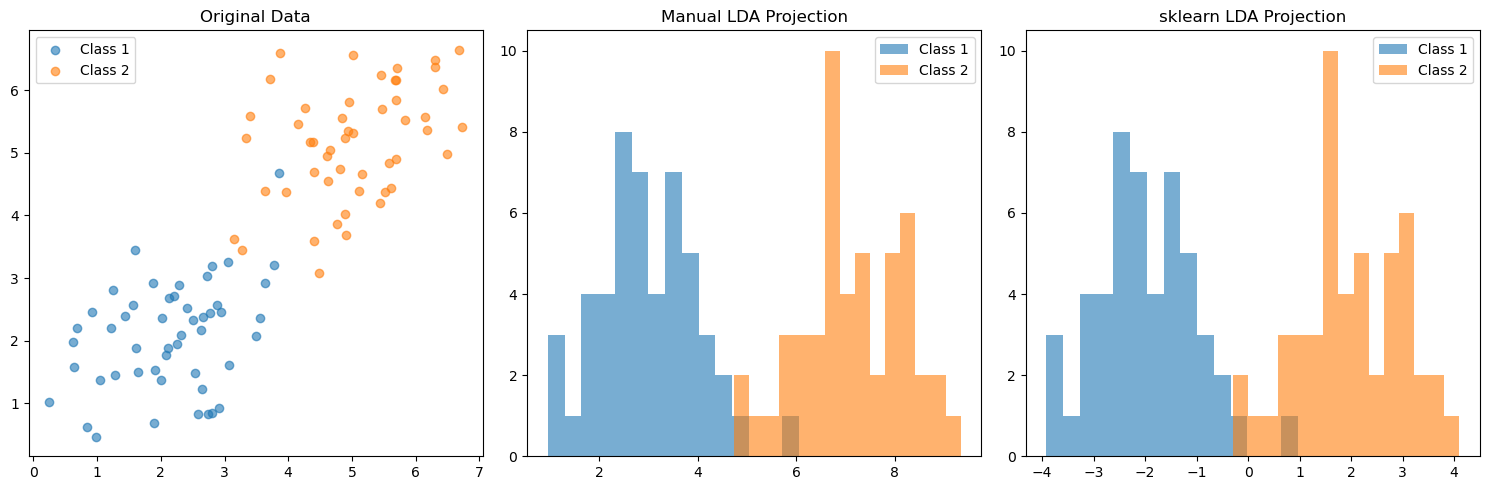

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Generate two-class data
np.random.seed(42)
class1 = np.random.multivariate_normal(mean=[2, 2], cov=[[1, 0.5], [0.5, 1]], size=50)
class2 = np.random.multivariate_normal(mean=[5, 5], cov=[[1, 0.5], [0.5, 1]], size=50)

X = np.vstack([class1, class2])
y = np.array([0]*50 + [1]*50)

# -----------------------------
# Manual Fisher LDA
# -----------------------------
# Compute class means
mean1 = np.mean(class1, axis=0)
mean2 = np.mean(class2, axis=0)

# Compute scatter matrices
S1 = np.cov(class1, rowvar=False)
S2 = np.cov(class2, rowvar=False)
Sw = S1 + S2  # Within-class scatter matrix

# Compute Fisher’s linear discriminant
w = np.linalg.inv(Sw).dot(mean2 - mean1)  # Projection vector
w /= np.linalg.norm(w)  # Normalize

# Project data onto the discriminant axis
proj1_manual = class1 @ w
proj2_manual = class2 @ w

# -----------------------------
# sklearn LDA
# -----------------------------
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X, y)

proj1_sklearn = X_lda[y == 0]
proj2_sklearn = X_lda[y == 1]

# -----------------------------
# Visualization
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot original data
axes[0].scatter(class1[:, 0], class1[:, 1], label='Class 1', alpha=0.6)
axes[0].scatter(class2[:, 0], class2[:, 1], label='Class 2', alpha=0.6)
axes[0].set_title("Original Data")
axes[0].legend()

# Manual LDA projection
axes[1].hist(proj1_manual, alpha=0.6, label='Class 1', bins=15)
axes[1].hist(proj2_manual, alpha=0.6, label='Class 2', bins=15)
axes[1].set_title("Manual LDA Projection")
axes[1].legend()

# sklearn LDA projection
axes[2].hist(proj1_sklearn, alpha=0.6, label='Class 1', bins=15)
axes[2].hist(proj2_sklearn, alpha=0.6, label='Class 2', bins=15)
axes[2].set_title("sklearn LDA Projection")
axes[2].legend()

plt.tight_layout()
plt.show()
